#### Semantic Analysis and Visualization of Tweets from Public Figures
- Andre Sae & Kyle Castillo
- November 6, 2025
- CS 329E - Elements of Data Visualization

**Research Question and Learning Model**

Research Question:
> How do tweets from Barack Obama, Cristiano Ronaldo, and Shakira differ in language and content, and can we visualize meaningful clusters by author using tweet semantics?

Learning Model / Approach:
- Type: Unsupervised learning / clustering visualization.
- Method: Use semantic embeddings + t-SNE to reveal natural groupings in tweet content.
- Goal: Identify clusters corresponding to authors based on tweet characteristics.

**Current Expectations About the Results**

- Tweets from the same author will cluster together in the 2D plot because similar writing style and topics produce similar embeddings.
- Expect three main clusters roughly corresponding to the three authors.
- Overlaps may occur for very generic content (e.g., inspirational quotes), but overall semantic differences should be visible.

**How to Evaluate the Project**

- Visual inspection: Check if tweets from the same author cluster together.


**Expected Model Performance:**

- t-SNE + embeddings should clearly separate authors semantically.
- Clustering quality depends on how distinct the authors’ language is; moderate to strong separation in 2D visualization is expected.

In [12]:
### 1. Import Libraries
import re

import matplotlib.pyplot as plt
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE

**What Is Your Dataset About?**

The dataset contains tweets from multiple public figures/accounts:

- Columns include: `author`, `content`, `date_time`, `number_of_likes`, `number_of_shares`.
- Focused on tweets from three authors: `BarackObama`, `Cristiano`, `shakira`.
- Each tweet is short text with metadata like posting date and engagement metrics.

In [ ]:
# Load and Prepare Data

# Define authors and sample size
TARGET_AUTHORS = ["katyperry", "cnnbrk", "Twitter"]
SAMPLE_SIZE = 2000

# Load CSV
df_ed = pd.read_csv("tweets_parsed_eddington.csv")
df_arch = pd.read_csv("tweets_parsed.csv")



C:\Users\kylec\AppData\Local\Temp\ipykernel_5372\502523248.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby("author", group_keys=False).apply(


**Data Cleaning and Reduction**

- Filtering: Kept only tweets from the three selected authors.
- Sampling: Randomly sampled 50 tweets per author to maintain balance and reduce size.
- Cleaning: Removed URLs, mentions, hashtags, punctuation, and normalized whitespace.
- Dimensionality reduction: Text converted to embeddings and reduced to 2D using t-SNE for visualization.

In [14]:
# Text Cleaning

# Removes URLs, mentions, hashtags, punctuation, and whitespace
def clean_tweet(text):
    """Cleans raw tweet text by removing URLs, mentions, hashtags, and punctuation."""
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"https?://\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# Apply cleaning function
df["content_cleaned"] = df["content"].apply(clean_tweet)

# Convert date_time column to datetime format
df["date_time"] = pd.to_datetime(df["date_time"], format="%d/%m/%Y %H:%M")

# Drop any rows where date parsing failed
df = df.dropna(subset=["date_time"]).reset_index(drop=True)

**Describe the Model You Are Using:**

We are using SentenceTransformer embeddings followed by t-SNE for dimensionality reduction.

- SentenceTransformer converts each tweet into a dense vector that captures semantic meaning. Tweets with similar content will have similar vectors.

- t-SNE (t-distributed Stochastic Neighbor Embedding) projects high-dimensional vectors into 2D space while preserving local neighborhoods, allowing us to visualize clusters.

This combination allows us to visually explore patterns in tweet content across different authors.

In [15]:
# Embed tweet content using SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = model.encode(df["content_cleaned"].tolist(), show_progress_bar=True)

# Reduce embeddings to 2D using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
features_2d = tsne.fit_transform(embeddings)

# Add 2D features back to DataFrame
df["tsne_1"] = features_2d[:, 0]
df["tsne_2"] = features_2d[:, 1]

Batches:   0%|          | 0/188 [00:00<?, ?it/s]

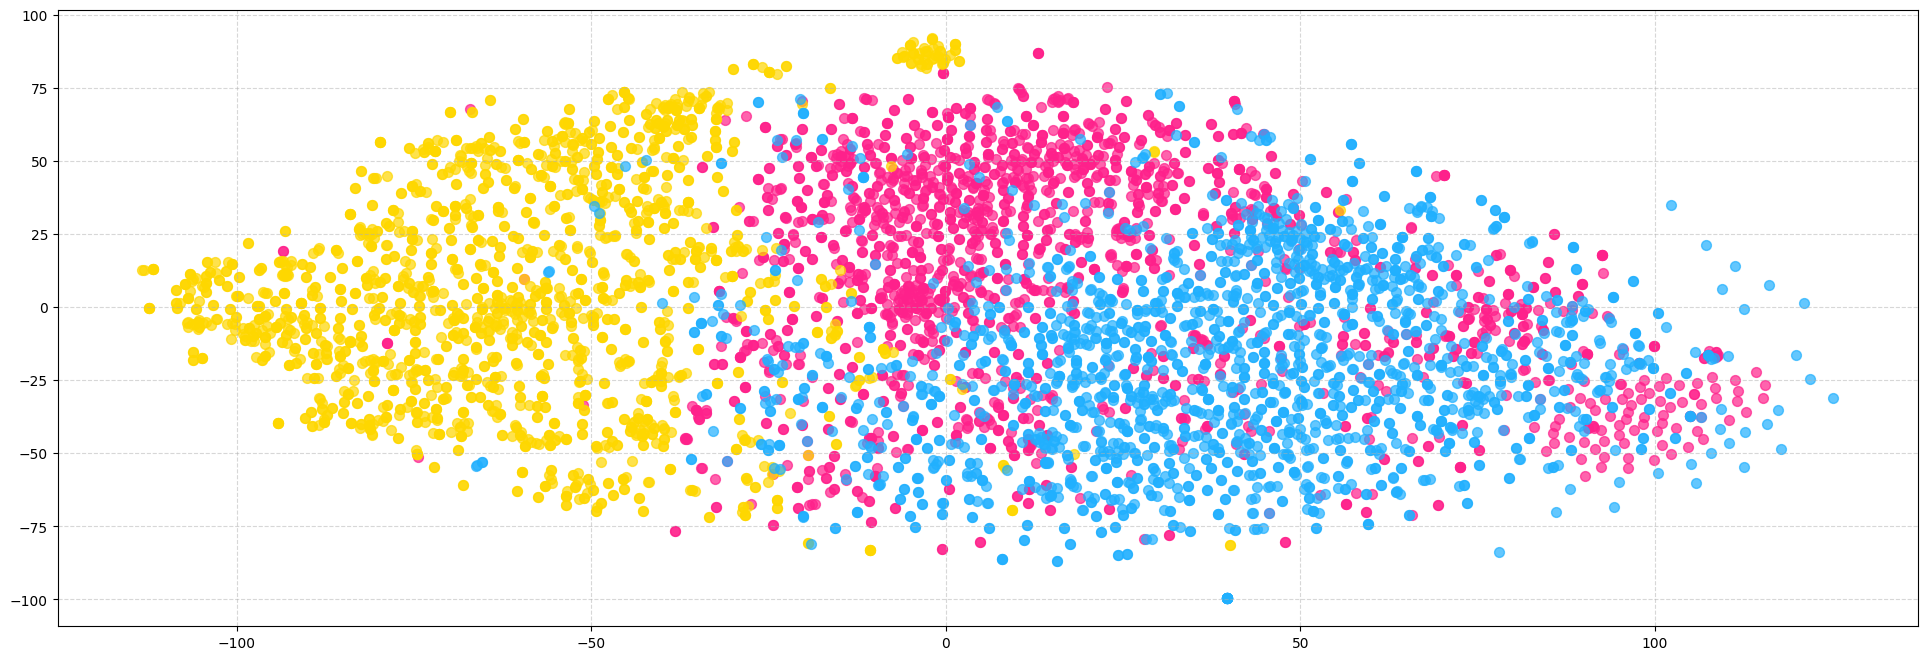

In [ ]:
### 5. Visualize Results

plt.figure(figsize=(24, 8))

colors = ["#fe218b", "#fed700", "#21b0fe"]

for i, author in enumerate(df["author"].unique()):
    subset = df[df["author"] == author]
    plt.scatter(
        subset["tsne_1"],
        subset["tsne_2"],
        label=author,
        alpha=0.7,
        s=50,  # marker size
        color=colors[i]
    )

# plt.title("t-SNE Visualization of Tweet Embeddings by Author")
# plt.xlabel("t-SNE Component 1")
# plt.ylabel("t-SNE Component 2")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**Interpretations**

- The t-SNE visualization shows that tweets from the same author tend to cluster together, indicating that each author has a distinct style and semantic pattern in their tweets.
- Barack Obama and Cristiano Ronaldo's cluster around Shakira's tweets but eventually meet in the middle. Shakira seems to be the bridge linking Obama and Ronaldo's tweets together.
- Some overlap may occur for generic or widely used phrases, but overall semantic differences are visible.

**Ideas to Improve Results**

- Increase sample size: Using more tweets per author will give t-SNE more data to form meaningful clusters.
- Include additional features: Incorporate metadata such as likes, shares, or hashtags to enrich clustering.

**References**

- scikit-learn TSNE Documentation: [https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html)  
- GeeksforGeeks. *t-SNE Algorithm in Machine Learning*. [https://www.geeksforgeeks.org/t-sne-algorithm-in-machine-learning/](https://www.geeksforgeeks.org/t-sne-algorithm-in-machine-learning/)  
- We lightly used Generative AI to reword ideas for better clarity and flow for our reader.